In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from pathlib import Path
from xgboost import XGBRegressor

In [3]:
PROJECT_ROOT = Path('__file__').resolve().parent.parent
csv_path = PROJECT_ROOT / "data" / "processed_stock_data.csv" # setting the csv raw file path
csv_path

WindowsPath('D:/IndianStockMarketAnalysis/data/processed_stock_data.csv')

In [6]:
df = pd.read_csv(csv_path)
df["Date"] = pd.to_datetime(df["Date"])

df.head()

,Date,Close,High,Low,Open,Volume,Stock,Return,MA20,MA50,Volatility,RSI,MACD,Trend
0,2025-03-20,872.580322,875.170313,862.985046,865.303681,17833978,HDFC BANK,NaN,NaN,NaN,NaN,NaN,NaN,Sideways
1,2025-03-21,873.369690,875.219684,866.068418,866.068418,33508264,HDFC BANK,0.000905,NaN,NaN,NaN,NaN,NaN,Sideways
2,2025-03-24,887.996948,890.167619,874.997672,877.636984,17393736,HDFC BANK,0.016748,NaN,NaN,NaN,NaN,NaN,Sideways
3,2025-03-25,898.578918,909.555548,888.736976,890.414316,39101416,HDFC BANK,0.011917,NaN,NaN,NaN,NaN,NaN,Sideways
4,2025-03-26,891.228333,901.563607,888.983649,900.330278,24478442,HDFC BANK,-0.008180,NaN,NaN,NaN,NaN,NaN,Sideways


In [7]:
stock_df = df[df["Stock"] == "RELIANCE"].copy()

stock_df = stock_df.sort_values("Date")
stock_df = stock_df.dropna()

In [8]:
stock_df["Target"] = stock_df["Close"].shift(-1)

stock_df = stock_df.dropna()

In [9]:
features = [
    "Open",
    "High",
    "Low",
    "Close",
    "Volume",
    "MA20",
    "MA50",
    "RSI",
    "MACD",
    "Volatility"
]

X = stock_df[features]
y = stock_df["Target"]

In [10]:
split = int(len(stock_df) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [11]:
model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5
)

model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [12]:
preds = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, preds))

print("RMSE:", rmse)

RMSE: 21.529917984285976


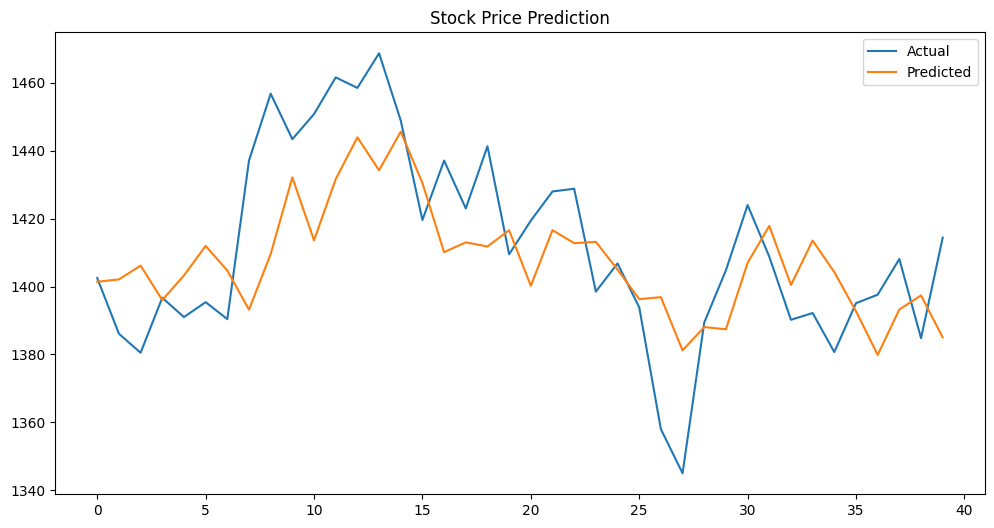

In [13]:
plt.figure(figsize=(12,6))

plt.plot(y_test.values, label="Actual")
plt.plot(preds, label="Predicted")

plt.title("Stock Price Prediction")
plt.legend()
plt.show()

In [14]:
latest_data = X.iloc[-1:]

next_price = model.predict(latest_data)

print("Predicted Next Close:", next_price[0])

Predicted Next Close: 1385.0145


In [ ]:
y.iloc[-1:]

745    1414.400024
Name: Target, dtype: float64

In [17]:
# save the model
import joblib
save_path = PROJECT_ROOT / "models" / "reliance_model.pkl"
joblib.dump(model, save_path)

['D:\\IndianStockMarketAnalysis\\models\\reliance_model.pkl']

In [ ]:
def train_model(stock_name):

    data = df[df["Stock"] == stock_name].copy()
    data = data.sort_values("Date").dropna()

    data["Target"] = data["Close"].shift(-1)
    data = data.dropna()

    X = data[features]
    y = data["Target"]

    split = int(len(data)*0.8)

    model = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=5)

    model.fit(X[:split], y[:split])

    return model